# Anàlisi micro del model `best_nash`

Còpia parametritzada de l'anàlisi del Checkpoint 3 (un dels 5 candidats). Es simulen partides contra `RandomAgent`, les 6 variants de l'`AgentRegles` i si mateix, registrant **cada decisió** amb el seu context (força de mà, punts d'envit, ronda, marcador, posició) i la distribució de probabilitats del policy.

---

In [1]:
import sys, random, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gymnasium.spaces import Box
import torch
import torch.nn as nn

sys.path.insert(0, str(Path('../utils')))
from nb_utils import setup_pyplot
setup_pyplot()

BASE = Path('../../../'); ROOT = BASE.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy.core
sys.modules.setdefault('numpy._core', numpy.core)
for _s in ['numeric','multiarray','umath','_multiarray_umath','numerictypes','_methods','fromnumeric','_dtype','overrides','shape_base']:
    try: sys.modules.setdefault(f'numpy._core.{_s}', importlib.import_module(f'numpy.core.{_s}'))
    except ImportError: pass

from stable_baselines3 import PPO
from rlcard.agents import RandomAgent
from RL.models.sb3.sb3_features_extractor import CosMultiInputSB3
from RL.models.sb3.sb3_adapter import SB3PPOEvalAgent
from RL.models.nfsp.average_policy import AveragePolicyNet, SLAgent
from RL.models.model_propi.agent_regles import AgentRegles
from RL.entrenament.entrenamentsComparatius.fase4.pool_oponents import crear_oponent
from joc.entorn.cartes_accions import ACTION_LIST
from joc.entorn.env import TrucEnv
from RL.entrenament.entrenamentsComparatius.fase2.entrenament_fase2_curriculum import ENV_CONFIG

# === Model a analitzar (un dels 5 candidats del Checkpoint 3) ===
MODEL_NAME = 'best_nash'
MODEL_KIND = 'ppo'              # 'ppo' (SB3) o 'sl' (AveragePolicyNet)
MODEL_PATH = (BASE / 'TFG_Doc/notebooks/6_nfsp/resultats/ppo_nfsp/best_nash.zip').resolve()
FIG_DIR = (BASE / 'TFG_Doc/Memoria/figures/resultats').resolve(); FIG_DIR.mkdir(parents=True, exist_ok=True)
VARIANTS = ['conservador','agressiu','truc_bot','envit_bot','faroler','equilibrat']

def carregar_ppo(zip_path):
    _orig = PPO.set_parameters
    def _patch(self, d, exact_match=True, device='auto'):
        if isinstance(d, dict): d = {k: v for k, v in d.items() if 'optimizer' not in k}
        return _orig(self, d, exact_match=False, device=device)
    PPO.set_parameters = _patch
    try:
        m = PPO.load(str(zip_path), custom_objects={'features_extractor_class': CosMultiInputSB3}, device='cpu')
    finally:
        PPO.set_parameters = _orig
    return SB3PPOEvalAgent(model=m, n_actions=24)

def carregar_sl(sl_path):
    sd = torch.load(str(sl_path), map_location='cpu', weights_only=True)
    net = object.__new__(AveragePolicyNet); nn.Module.__init__(net)
    net.cos = CosMultiInputSB3(observation_space=Box(low=-1, high=1, shape=(240,)), features_dim=256)
    layers, in_dim = [], 256
    for h in (256, 256):
        layers += [nn.Linear(in_dim, h), nn.ReLU()]; in_dim = h
    layers += [nn.Linear(in_dim, 24)]
    net.head = nn.Sequential(*layers)
    net.load_state_dict(sd)
    return SLAgent(net=net, device='cpu', deterministic=False, seed=42)

def carregar_model():
    return carregar_sl(MODEL_PATH) if MODEL_KIND == 'sl' else carregar_ppo(MODEL_PATH)

ar = AgentRegles(num_actions=24, seed=0)   # només per als seus extractors de context
print(f'Model: {MODEL_NAME} ({MODEL_KIND}) | exists={MODEL_PATH.exists()} | FIG_DIR={FIG_DIR}')

Model: best_nash (ppo) | exists=True | FIG_DIR=C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\Memoria\figures\resultats


---

In [2]:
import torch
from RL.tools.obs_utils import flatten_obs

def nom_accio(a):
    return ACTION_LIST[a] if a < len(ACTION_LIST) else f'accio_{a}'

def cat_accio(nom):
    if nom.startswith('play_card'): return 'jugar_carta'
    if nom.startswith('senya'): return 'senya'
    return nom

def bucket_forca(hs):
    if hs < 0.50: return 'feble'
    if hs < 0.59: return 'mitjana'
    if hs < 0.65: return 'forta'
    return 'molt forta'
ORDRE_FORCA = ['feble','mitjana','forta','molt forta']

def bucket_envit(e):
    if e < 23: return 'baix'
    if e < 30: return 'mig'
    return 'alt'
ORDRE_ENVIT = ['baix','mig','alt']

# Índexs d'accions per treure les probabilitats del policy
I_TRUC = ACTION_LIST.index('apostar_truc'); I_ENVIT = ACTION_LIST.index('apostar_envit')
I_VT = ACTION_LIST.index('vull_truc');     I_FT = ACTION_LIST.index('fora_truc')
I_VE = ACTION_LIST.index('vull_envit');    I_FE = ACTION_LIST.index('fora_envit')

def _decidir_sb3(sb3_model, state):
    """Una sola passada: retorna acció (argmax->legal, com deterministic=True),
    probabilitats renormalitzades sobre legals i entropia."""
    of = flatten_obs(state['obs']).astype(np.float32)
    with torch.no_grad():
        p = sb3_model.policy.get_distribution(torch.as_tensor(of[np.newaxis])).distribution.probs.cpu().numpy()[0]
    leg = list(state['legal_actions'].keys())
    a = int(p.argmax())
    if a not in leg: a = leg[0]
    tot = sum(p[k] for k in leg) + 1e-12
    pl = {k: p[k] / tot for k in leg}
    ent = -sum(v * np.log(v + 1e-12) for v in pl.values())
    return a, pl, ent

def _decidir_sl(sl_agent, state):
    """Equivalent per a l'SLAgent (AveragePolicyNet): softmax dels logits i
    renormalitza sobre les accions legals. Acció = argmax (com deterministic=True)."""
    of = flatten_obs(state['obs']).astype(np.float32)
    with torch.no_grad():
        logits = sl_agent.net(torch.as_tensor(of[np.newaxis])).cpu().numpy()[0]
    p = np.exp(logits - logits.max()); p = p / p.sum()
    leg = list(state['legal_actions'].keys())
    a = int(p.argmax())
    if a not in leg: a = leg[0]
    tot = sum(p[k] for k in leg) + 1e-12
    pl = {k: p[k] / tot for k in leg}
    ent = -sum(v * np.log(v + 1e-12) for v in pl.values())
    return a, pl, ent

def context(raw):
    g, p = ar._rondes_info(raw)
    eq = raw['id_jugador'] % 2; pf = raw.get('puntuacio_final', 24)
    pp = raw['puntuacio'][eq]; prv = raw['puntuacio'][1 - eq]
    maxp = max(pp, prv)
    fase = 'inici' if maxp < 8 else ('mig' if maxp < 16 else 'final')
    av = pp - prv
    situacio = 'igualat' if av == 0 else ('davant' if av > 0 else 'darrere')
    return dict(hand_strength=ar._hand_strength(raw), envit_score=ar._envit_score(raw),
                best_force=ar._best_force(raw), num_ronda=min(g + p + 1, 3),
                avantatge=av, situacio=situacio, som_ma=ar._som_ma(raw),
                fase=fase, response_state=raw['response_state_val'])

def jugar_i_registrar(model, oponent, nom_op, n, seed):
    rng = random.Random(seed); dec = []; res = []
    te_probs = hasattr(model, 'model') or hasattr(model, 'net')   # SB3 PPO o SL -> distribució
    PCOLS = ['p_truc','p_envit','p_vull_truc','p_fora_truc','p_vull_envit','p_fora_envit','entropia']
    for i in range(n):
        mpos = i % 2
        agents = [model, oponent] if mpos == 0 else [oponent, model]
        cfg = ENV_CONFIG.copy(); cfg['seed'] = rng.randint(0, 2**31 - 1)
        env = TrucEnv(cfg); env.set_agents(agents)
        state, pid = env.reset()
        while pid is not None:
            if pid == mpos:
                if hasattr(model, 'model'):
                    a, pl, ent = _decidir_sb3(model.model, state)
                elif hasattr(model, 'net'):
                    a, pl, ent = _decidir_sl(model, state)
                else:
                    a, _ = agents[pid].eval_step(state); pl, ent = None, np.nan
                raw = state['raw_obs']; legals = set(state['legal_actions'].keys())
                lt = ('apostar_truc' in [nom_accio(k) for k in legals])
                le = ('apostar_envit' in [nom_accio(k) for k in legals])
                nom = nom_accio(a)
                row = context(raw)
                row.update(accio_nom=nom, accio_cat=cat_accio(nom), oponent=nom_op,
                           legal_truc=lt, legal_envit=le)
                if te_probs:
                    row['p_truc'] = pl.get(I_TRUC, np.nan) if lt else np.nan
                    row['p_envit'] = pl.get(I_ENVIT, np.nan) if le else np.nan
                    row['p_vull_truc'] = pl.get(I_VT, np.nan); row['p_fora_truc'] = pl.get(I_FT, np.nan)
                    row['p_vull_envit'] = pl.get(I_VE, np.nan); row['p_fora_envit'] = pl.get(I_FE, np.nan)
                    row['entropia'] = ent
                else:
                    for c in PCOLS: row[c] = np.nan
                dec.append(row)
            else:
                a, _ = agents[pid].eval_step(state)
            state, pid = env.step(a)
        sc = env.game.score
        res.append(dict(oponent=nom_op, win=int(sc[mpos] > sc[1 - mpos]),
                        punts_propi=sc[mpos], punts_rival=sc[1 - mpos]))
    return pd.DataFrame(dec), pd.DataFrame(res)

print('Harness OK (SB3 + SL: probabilitats i entropia, una sola passada)')

Harness OK (SB3 + SL: probabilitats i entropia, una sola passada)


## 1. Recollida de dades

In [3]:
N = 1000
model = carregar_model()
oponents = {'random': RandomAgent(num_actions=24)}
for v in VARIANTS:
    oponents[v] = crear_oponent(v, seed=42)
oponents['self'] = carregar_model()

decs, ress = [], []
for nom, op in oponents.items():
    d, r = jugar_i_registrar(model, op, nom, N, seed=1000)
    decs.append(d); ress.append(r)
    print(f'  {nom:<12} {len(d):>5} decisions  WR={r.win.mean()*100:5.1f}%')
dec = pd.concat(decs, ignore_index=True)
res = pd.concat(ress, ignore_index=True)
print(f'\nTotal decisions del model: {len(dec)}  | partides: {len(res)}')

  random       13824 decisions  WR= 88.9%
  conservador  15466 decisions  WR= 74.8%
  agressiu     13816 decisions  WR= 55.0%
  truc_bot     12686 decisions  WR= 62.7%
  envit_bot    17472 decisions  WR= 71.1%
  faroler      12997 decisions  WR= 61.5%
  equilibrat   13560 decisions  WR= 71.1%
  self          7789 decisions  WR= 49.8%

Total decisions del model: 107610  | partides: 8000


In [4]:
# Línia base d'estil: AgentRegles equilibrat contra el mateix conjunt d'oponents
N_BASE = 1000
ar_base = crear_oponent('equilibrat', seed=7)
ops_base = {'random': RandomAgent(num_actions=24)}
for v in VARIANTS:
    ops_base[v] = crear_oponent(v, seed=99)
decs_ar = []
for nom, op in ops_base.items():
    d, _ = jugar_i_registrar(ar_base, op, nom, N_BASE, seed=2000)
    decs_ar.append(d)
dec_ar = pd.concat(decs_ar, ignore_index=True)
print(f'Decisions AgentRegles equilibrat (base): {len(dec_ar)}  | partides: {N_BASE*len(ops_base)}')

Decisions AgentRegles equilibrat (base): 351990  | partides: 7000


## 2. Rendiment clàssic

               WR  punts_propi  punts_rival
oponent                                    
random       88.9         27.9          5.5
conservador  74.8         24.3          8.9
agressiu     55.0         19.1         13.9
truc_bot     62.7         20.4         10.5
envit_bot    71.1         23.7         11.9
faroler      61.5         20.0         11.9
equilibrat   71.1         22.3          9.8
self         49.8         12.8         12.9


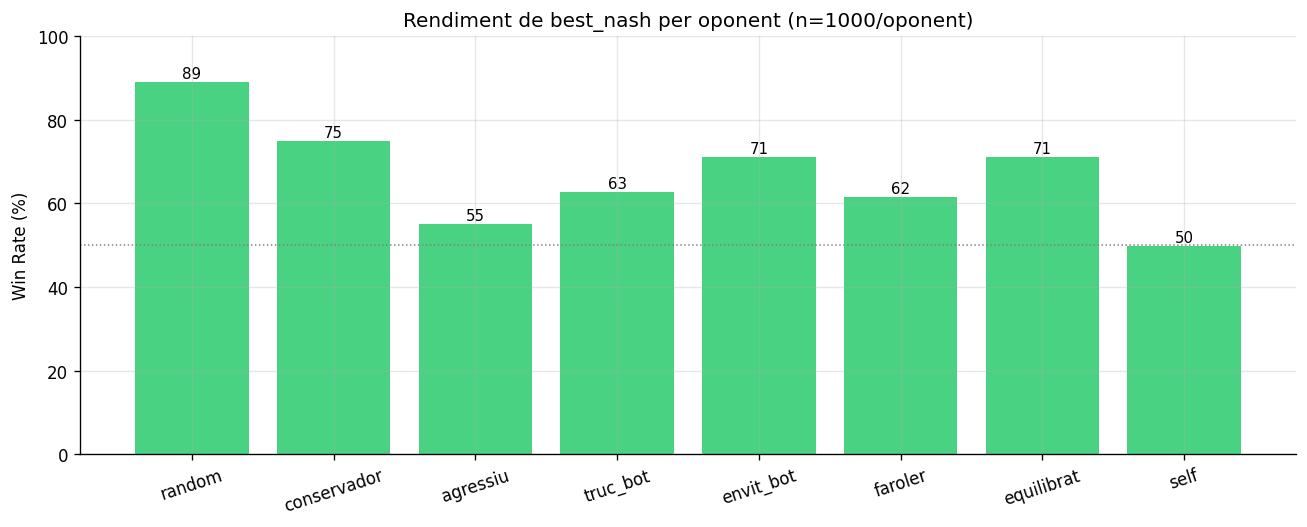

In [5]:
tab = res.groupby('oponent').agg(WR=('win', lambda s: round(s.mean()*100, 1)),
                                 punts_propi=('punts_propi', 'mean'),
                                 punts_rival=('punts_rival', 'mean')).round(1)
ordre = ['random'] + VARIANTS + ['self']
tab = tab.reindex(ordre)
print(tab.to_string())

n_per_op = len(res) // len(ordre)
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(ordre))
ax.bar(x, tab['WR'], color='#2ecc71', alpha=0.88)
ax.axhline(50, color='gray', ls=':', lw=0.9)
for i, v in enumerate(tab['WR']): ax.text(i, v + 1, f'{v:.0f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(ordre, rotation=18)
ax.set_ylabel('Win Rate (%)'); ax.set_ylim(0, 100)
ax.set_title(f'Rendiment de {MODEL_NAME} per oponent (n={n_per_op}/oponent)')
plt.tight_layout(); fig.savefig(FIG_DIR / 'rendiment_oponents.pdf', bbox_inches='tight'); plt.show()

## 3. Perfil d'estil emergent (vs AgentRegles equilibrat)

P% = probabilitat mitjana del policy (tova)  |  det% = freqüència realitzada (determinista)

                         mà  P%  segon P%  global P%  global det%  AgRegles det%
Obre truc                  51.4      48.8       50.3         78.2           15.7
Accepta truc (no fold)     98.5      98.8       98.6        100.0           30.9
Reapuja truc (retruc)      61.5      66.3       63.8         58.8            9.0
Obre envit                  9.5      10.3        9.7         23.7           40.8
Accepta envit (no fold)    77.7      65.6       70.1         70.7           39.6
Reapuja envit              13.9      41.2       31.0         24.6           19.8

Entropia del policy: mitjana=0.814  mediana=0.7833  (màx amb 6 accions=1.79)  |  9% decisions quasi-deterministes


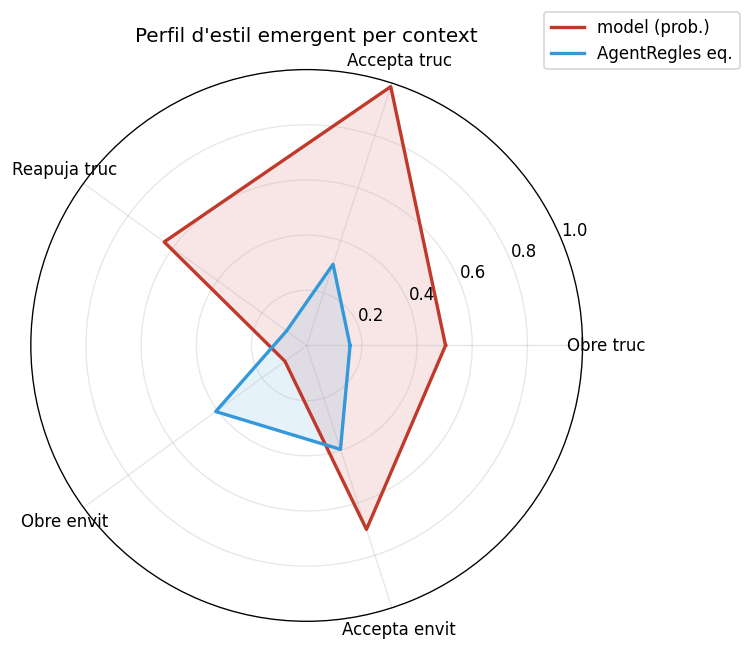

In [6]:
# --- Perfil d'estil DIFERENCIAT PER CONTEXT, amb probabilitat (tova) i realitzat (dur) ---
def ctx_metrics(df, soft):
    rs0 = df[df.response_state == 0]; r1 = df[df.response_state == 1]; r2 = df[df.response_state == 2]
    ot = rs0[rs0.legal_truc]; oe = rs0[rs0.legal_envit]
    r1l = r1[r1.legal_truc]; r2l = r2[r2.legal_envit]    # podia retrucar / re-envidar
    def H(d, v):    return float((d.accio_nom == v).mean()) if len(d) else np.nan
    def Hn(d, v):   return float((d.accio_nom != v).mean()) if len(d) else np.nan
    def S(d, c):    return float(d[c].mean()) if len(d) and d[c].notna().any() else np.nan
    m = {'obre_truc': H(ot, 'apostar_truc'), 'accepta_truc': Hn(r1, 'fora_truc'),
         'reapuja_truc': H(r1l, 'apostar_truc'), 'obre_envit': H(oe, 'apostar_envit'),
         'accepta_envit': Hn(r2, 'fora_envit'), 'reapuja_envit': H(r2l, 'apostar_envit')}
    if soft:
        m = {**m, 'obre_truc_p': S(ot, 'p_truc'),
             'accepta_truc_p': (1 - S(r1, 'p_fora_truc')) if len(r1) else np.nan,
             'reapuja_truc_p': S(r1l, 'p_truc'), 'obre_envit_p': S(oe, 'p_envit'),
             'accepta_envit_p': (1 - S(r2, 'p_fora_envit')) if len(r2) else np.nan,
             'reapuja_envit_p': S(r2l, 'p_envit')}
    return m

mm  = {pos: ctx_metrics(dec[dec.som_ma] if pos=='mà' else dec[~dec.som_ma] if pos=='segon' else dec, True)
       for pos in ['mà','segon','global']}
ar_m = ctx_metrics(dec_ar, False)

CTX = ['obre_truc','accepta_truc','reapuja_truc','obre_envit','accepta_envit','reapuja_envit']
NOM = {'obre_truc':'Obre truc','accepta_truc':'Accepta truc (no fold)','reapuja_truc':'Reapuja truc (retruc)',
       'obre_envit':'Obre envit','accepta_envit':'Accepta envit (no fold)','reapuja_envit':'Reapuja envit'}
tab = pd.DataFrame({
    'mà  P%':     [mm['mà'].get(k+'_p',np.nan)*100 for k in CTX],
    'segon P%':   [mm['segon'].get(k+'_p',np.nan)*100 for k in CTX],
    'global P%':  [mm['global'].get(k+'_p',np.nan)*100 for k in CTX],
    'global det%':[mm['global'][k]*100 for k in CTX],
    'AgRegles det%':[ar_m[k]*100 for k in CTX],
}, index=[NOM[k] for k in CTX]).round(1)
print('P% = probabilitat mitjana del policy (tova)  |  det% = freqüència realitzada (determinista)\n')
print(tab.to_string())
print(f'\nEntropia del policy: mitjana={dec.entropia.mean():.3f}  mediana={dec.entropia.median():.4f}  '
      f'(màx amb 6 accions={np.log(6):.2f})  |  {(dec.entropia<0.05).mean()*100:.0f}% decisions quasi-deterministes')

# Radar: model (probabilitat tova) vs AgentRegles (freqüència) sobre 5 eixos de context
eixos = ['obre_truc','accepta_truc','reapuja_truc','obre_envit','accepta_envit']
labels = ['Obre truc','Accepta truc','Reapuja truc','Obre envit','Accepta envit']
ang = np.linspace(0, 2*np.pi, len(eixos), endpoint=False).tolist(); ang += ang[:1]
fig, ax = plt.subplots(figsize=(6.4, 6.4), subplot_kw=dict(polar=True))
series = [('model (prob.)', [mm['global'][e+'_p'] for e in eixos], '#c0392b'),
          ('AgentRegles eq.', [ar_m[e] for e in eixos], '#3498db')]
for nom, vals, col in series:
    v = vals + vals[:1]
    ax.plot(ang, v, color=col, lw=2, label=nom); ax.fill(ang, v, color=col, alpha=0.12)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels); ax.set_ylim(0, 1)
ax.set_title("Perfil d'estil emergent per context")
ax.legend(loc='upper right', bbox_to_anchor=(1.30, 1.12))
plt.tight_layout(); fig.savefig(FIG_DIR / 'estil_radar.pdf', bbox_inches='tight'); plt.show()

## 4. Política condicionada: acció ↔ força de mà / envit

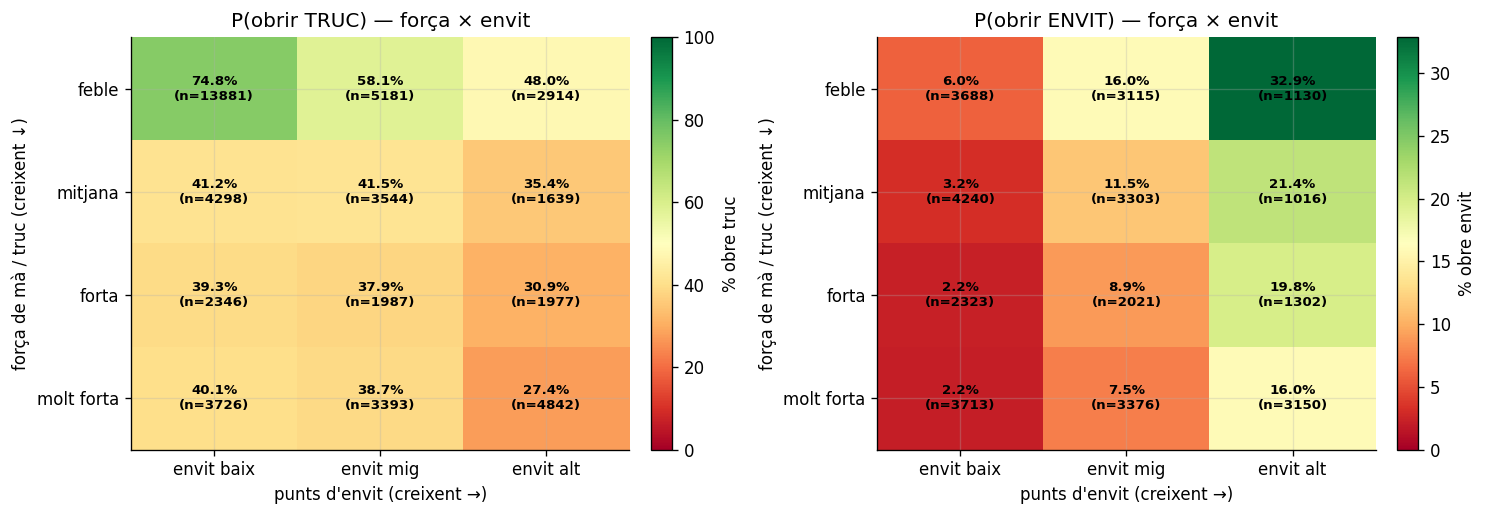

P(obrir TRUC) %% (prob. mitjana): envit_b     baix   mig   alt
forca                       
feble       74.8  58.1  48.0
mitjana     41.2  41.5  35.4
forta       39.3  37.9  30.9
molt forta  40.1  38.7  27.4
P(obrir ENVIT) %% (prob. mitjana): envit_b     baix    mig    alt
forca                         
feble       6.03  16.04  32.88
mitjana     3.18  11.54  21.36
forta       2.24   8.87  19.84
molt forta  2.18   7.49  16.01
n (obrir truc): envit_b      baix   mig   alt
forca                        
feble       13881  5181  2914
mitjana      4298  3544  1639
forta        2346  1987  1977
molt forta   3726  3393  4842
n (obrir envit): envit_b     baix   mig   alt
forca                       
feble       3688  3115  1130
mitjana     4240  3303  1016
forta       2323  2021  1302
molt forta  3713  3376  3150


In [7]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patches as mpatches

# JOINT forca x punts d'envit -> probabilitat d'OBRIR truc / envit.
rs0 = dec[dec.response_state == 0].copy()
rs0['forca'] = pd.Categorical(rs0.hand_strength.map(bucket_forca), ORDRE_FORCA, ordered=True)
rs0['envit_b'] = pd.Categorical(rs0.envit_score.map(bucket_envit), ORDRE_ENVIT, ordered=True)
ot = rs0[rs0.legal_truc]; oe = rs0[rs0.legal_envit]
jt = ot.pivot_table(index='forca', columns='envit_b', values='p_truc', aggfunc='mean', observed=False) * 100
je = oe.pivot_table(index='forca', columns='envit_b', values='p_envit', aggfunc='mean', observed=False) * 100
nt = ot.pivot_table(index='forca', columns='envit_b', values='p_truc', aggfunc='count', observed=False)
ne = oe.pivot_table(index='forca', columns='envit_b', values='p_envit', aggfunc='count', observed=False)

_nl = chr(10)  # nova linia dins f-string sense confondre JSON

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
im0 = axes[0].imshow(jt.values, cmap='RdYlGn', norm=TwoSlopeNorm(vmin=0, vcenter=50, vmax=100), aspect='auto')
axes[0].set_title('P(obrir TRUC) — força × envit')
vmaxe = float(np.nanmax(je.values))
im1 = axes[1].imshow(je.values, cmap='RdYlGn', vmin=0, vmax=max(vmaxe, 1e-6), aspect='auto')
axes[1].set_title('P(obrir ENVIT) — força × envit')

for ax, M, N in [(axes[0], jt, nt), (axes[1], je, ne)]:
    ax.set_xticks(range(len(M.columns))); ax.set_xticklabels(['envit ' + c for c in M.columns])
    ax.set_yticks(range(len(M.index))); ax.set_yticklabels(M.index)
    ax.set_xlabel("punts d'envit (creixent →)"); ax.set_ylabel('força de mà / truc (creixent ↓)')
    for i in range(len(M.index)):
        for j in range(len(M.columns)):
            v = M.values[i, j]; n = N.values[i, j]
            txt = '--' if np.isnan(v) else f'{v:.1f}%{_nl}(n={int(n)})'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8,
                    fontweight='bold', color='black', zorder=3)

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04).set_label('% obre truc')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04).set_label('% obre envit')
plt.tight_layout(); fig.savefig(FIG_DIR / 'accio_x_forca.pdf', bbox_inches='tight'); plt.show()
print('P(obrir TRUC) %% (prob. mitjana):', jt.round(1).to_string())
print('P(obrir ENVIT) %% (prob. mitjana):', je.round(2).to_string())
print('n (obrir truc):', nt.astype(int).to_string())
print('n (obrir envit):', ne.astype(int).to_string())

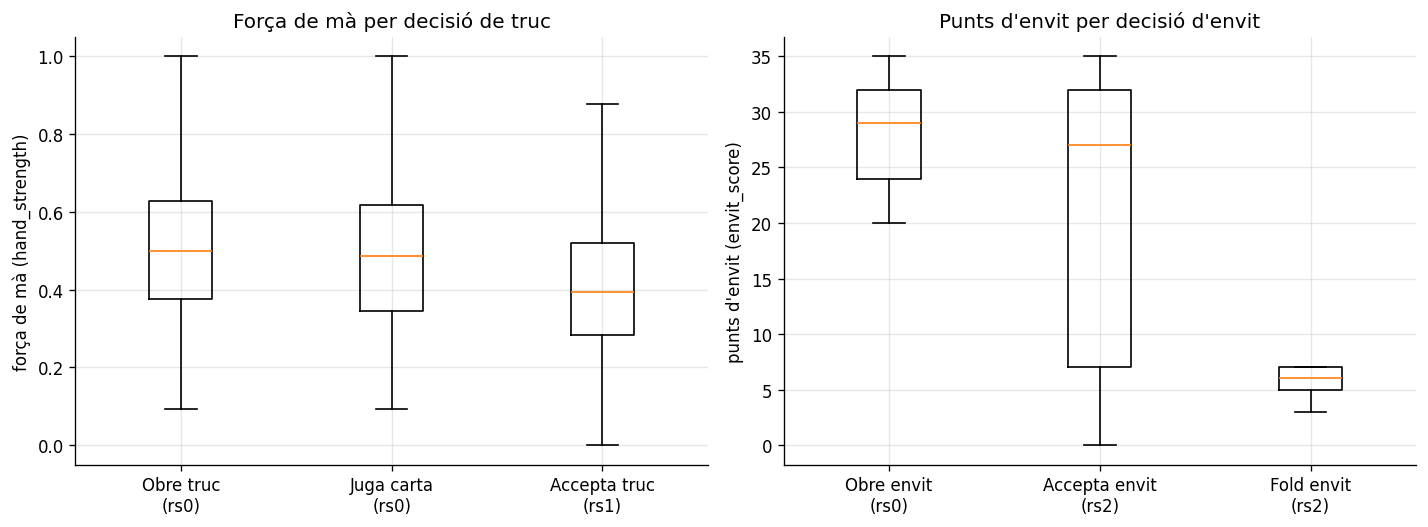

Obre truc (rs0)        n= 38899  hand_strength mediana=0.50
Juga carta (rs0)       n= 29071  hand_strength mediana=0.49
Accepta truc (rs1)     n= 13108  hand_strength mediana=0.39
---
Obre envit (rs0)       n=  7658  envit_score mediana=29.0
Accepta envit (rs2)    n=  4770  envit_score mediana=27.0
Fold envit (rs2)       n=  3031  envit_score mediana=6.0


In [8]:
# Boxplots amb el CONTEXT correcte de cada acció (no barreja estats).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Esquerra: força de mà segons l'acció de TRUC, cadascuna en el seu context
grups_truc = [
    ('Obre truc\n(rs0)',    dec[(dec.response_state == 0) & (dec.accio_nom == 'apostar_truc')].hand_strength),
    ('Juga carta\n(rs0)',   dec[(dec.response_state == 0) & (dec.accio_cat == 'jugar_carta')].hand_strength),
    ('Accepta truc\n(rs1)', dec[(dec.response_state == 1) & (dec.accio_nom == 'vull_truc')].hand_strength),
]
axes[0].boxplot([g.values for _, g in grups_truc], tick_labels=[n for n, _ in grups_truc], showfliers=False)
axes[0].set_ylabel('força de mà (hand_strength)'); axes[0].set_title('Força de mà per decisió de truc')
# Dreta: punts d'envit segons l'acció d'ENVIT, cadascuna en el seu context
grups_env = [
    ('Obre envit\n(rs0)',    dec[(dec.response_state == 0) & (dec.accio_nom == 'apostar_envit')].envit_score),
    ('Accepta envit\n(rs2)', dec[(dec.response_state == 2) & (dec.accio_nom == 'vull_envit')].envit_score),
    ('Fold envit\n(rs2)',    dec[(dec.response_state == 2) & (dec.accio_nom == 'fora_envit')].envit_score),
]
axes[1].boxplot([g.values for _, g in grups_env], tick_labels=[n for n, _ in grups_env], showfliers=False)
axes[1].set_ylabel("punts d'envit (envit_score)"); axes[1].set_title("Punts d'envit per decisió d'envit")
plt.tight_layout(); fig.savefig(FIG_DIR / 'forca_x_accio.pdf', bbox_inches='tight'); plt.show()
for nom, g in grups_truc:
    print(f"{nom.replace(chr(10),' '):<22} n={len(g):>6}  hand_strength mediana={g.median():.2f}" if len(g) else f"{nom}: buit")
print('---')
for nom, g in grups_env:
    print(f"{nom.replace(chr(10),' '):<22} n={len(g):>6}  envit_score mediana={g.median():.1f}" if len(g) else f"{nom}: buit")

## 5. Comportament contextual (quan fa cada acció)

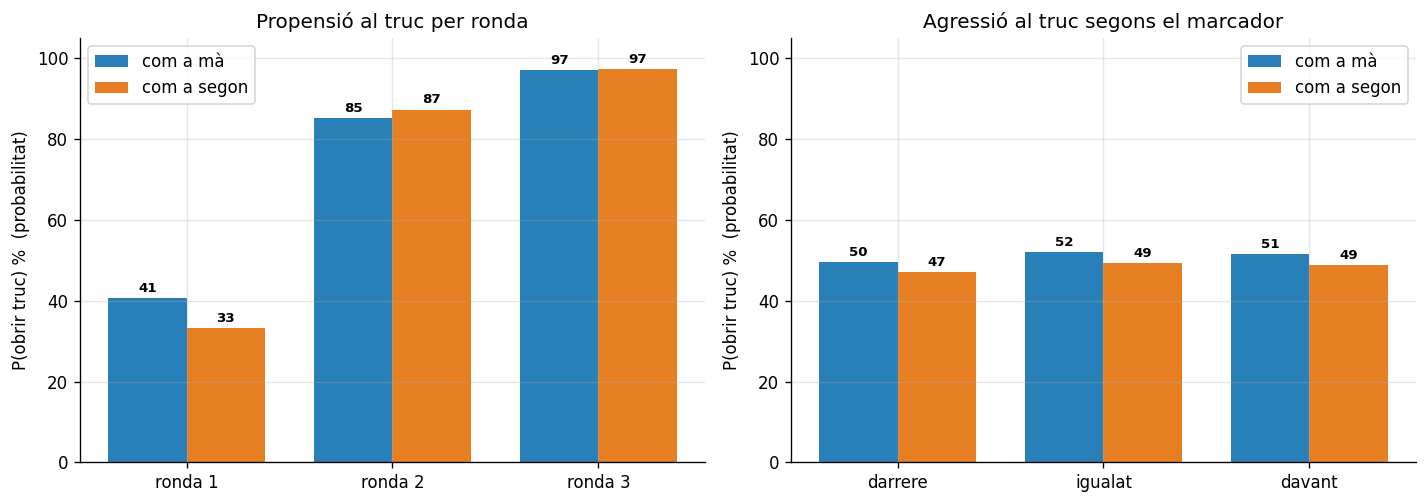

Truc/ronda  mà: [np.float64(40.7), np.float64(85.1), np.float64(97.0)] | segon: [np.float64(33.2), np.float64(87.3), np.float64(97.4)]
Truc/marcador mà: {'darrere': np.float64(49.6), 'igualat': np.float64(52.0), 'davant': np.float64(51.4)} | segon: {'darrere': np.float64(47.1), 'igualat': np.float64(49.4), 'davant': np.float64(48.9)}


In [9]:
# Comportament contextual del TRUC (propensió tova a OBRIR), separat per posició MÀ / SEGON.
ot = dec[(dec.response_state == 0) & (dec.legal_truc)].copy()
ordre_r = [1, 2, 3]; ordre_s = ['darrere', 'igualat', 'davant']
def prop_by(df, col, ordre):
    ma  = [df[(df[col] == v) & (df.som_ma)].p_truc.mean() * 100 for v in ordre]
    seg = [df[(df[col] == v) & (~df.som_ma)].p_truc.mean() * 100 for v in ordre]
    return ma, seg
ma_r, seg_r = prop_by(ot, 'num_ronda', ordre_r)
ma_s, seg_s = prop_by(ot, 'situacio', ordre_s)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3)); w = 0.38
def grouped(ax, etiquetes, ma, seg, titol):
    x = np.arange(len(etiquetes))
    ax.bar(x - w/2, ma, w, label='com a mà', color='#2980b9')
    ax.bar(x + w/2, seg, w, label='com a segon', color='#e67e22')
    ax.set_xticks(x); ax.set_xticklabels(etiquetes)
    ax.set_ylabel('P(obrir truc) %  (probabilitat)'); ax.set_ylim(0, 105); ax.set_title(titol); ax.legend()
    for i, (a, b) in enumerate(zip(ma, seg)):
        ax.text(i - w/2, a + 1.5, f'{a:.0f}', ha='center', fontsize=8, fontweight='bold')
        ax.text(i + w/2, b + 1.5, f'{b:.0f}', ha='center', fontsize=8, fontweight='bold')
grouped(axes[0], [f'ronda {r}' for r in ordre_r], ma_r, seg_r, 'Propensió al truc per ronda')
grouped(axes[1], ordre_s, ma_s, seg_s, "Agressió al truc segons el marcador")
plt.tight_layout(); fig.savefig(FIG_DIR / 'contextual.pdf', bbox_inches='tight'); plt.show()
print('Truc/ronda  mà:', [round(v, 1) for v in ma_r], '| segon:', [round(v, 1) for v in seg_r])
print('Truc/marcador mà:', dict(zip(ordre_s, [round(v, 1) for v in ma_s])),
      '| segon:', dict(zip(ordre_s, [round(v, 1) for v in seg_s])))

---
## Síntesi

Les cel·les anteriors caracteritzen el model desplegat a nivell micro: rendiment per
oponent, perfil d'estil emergent comparat amb l'`AgentRegles` equilibrat, com varia la
política segons la força de la mà i els punts d'envit, i com canvia el comportament segons
la ronda i el marcador. Aquests números alimenten la secció numèrica del capítol de Resultats.